In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from matplotlib.transforms import offset_copy
from matplotlib import colors
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [16]:
%run LittRuP__import_functions.ipynb

In [17]:
# chemins vers fichiers Data et Images

BASE_DIR = Path.cwd()
DAT_DIR = BASE_DIR / "Data"
IMG_DIR = BASE_DIR / "Images"

In [18]:
# import matrice étendue

matrix_all_extended = pd.read_csv(DAT_DIR / "LittRu_matrix_all_extended.csv", sep=',', header=0)

In [19]:
# indique que les thèmes sont toutes les colonnes situées après "CutOff"

theme_cols = matrix_all_extended.columns[
    matrix_all_extended.columns.get_loc("CutOff") + 1:
]

In [20]:
# matrice des thèmes 0/1

matrix_themes = matrix_all_extended[theme_cols]

In [21]:
# liste des thèmes

the_themes = matrix_themes.columns.values.tolist()

**Profils thématiques par périodes et par CutOff (profils normalisés)**

In [33]:
# profil thématique normalisé par rapport à périodes

matrix_when_profile_pct = (
    matrix_all_extended
    .groupby("When")[theme_cols]   # on ne prend que les thèmes
    .mean()
    * 100
)

In [34]:
# profil thématique normalisé par rapport à 1917

matrix_cutoff_profile_pct = (
    matrix_all_extended
    .groupby("CutOff")[theme_cols]   # on ne prend que les thèmes
    .mean()
    * 100
)

In [35]:
# nombre d'œuvres par période historique

n_when = matrix_all_extended.groupby("When").size()

matrix_when_profile_pct_plot = matrix_when_profile_pct.rename(
    index={
        periode: f"{periode}\nn={n_when.loc[periode]}"
        for periode in matrix_when_profile_pct.index
    }
)

In [36]:
# nombre d'œuvres avant / après 1917

n_cutoff = matrix_all_extended.groupby("CutOff").size()

matrix_cutoff_profile_pct_plot = matrix_cutoff_profile_pct.rename(
    index={
        periode: f"{periode}\nn={n_cutoff.loc[periode]}"
        for periode in matrix_cutoff_profile_pct.index
    }
)

**Heatmaps côte à côte**

In [37]:
# fonction de définition

def heatmap_profile(
    fig,
    ax,
    data,
    title,
    norm,
    show_yticklabels=True,
    show_ylabel=True
):
    
    sns.heatmap(
        data.T,
        cmap="hot_r",
        cbar=False,
        norm=norm,
        ax=ax
    )
    
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    
    ax.tick_params(axis="x", labelrotation=45, labelsize=9)
    ax.tick_params(axis="y", labelrotation=0, labelsize=9)
    
    for label in ax.get_yticklabels():
        label.set_fontsize(9)
        label.set_fontweight("normal")
        label.set_horizontalalignment("right")
        label.set_verticalalignment("center")
    
    ax.set_xlabel("Profils des périodes", fontsize=12, fontweight="bold")
    
    if show_yticklabels:
        ax.set_yticklabels(ax.get_yticklabels())
    else:
        ax.set_yticklabels([])
    
    if show_ylabel:
        ax.set_ylabel("Thèmes", fontsize=12, fontweight="bold")
    else:
        ax.set_ylabel("")
    
    return ax.collections[0]

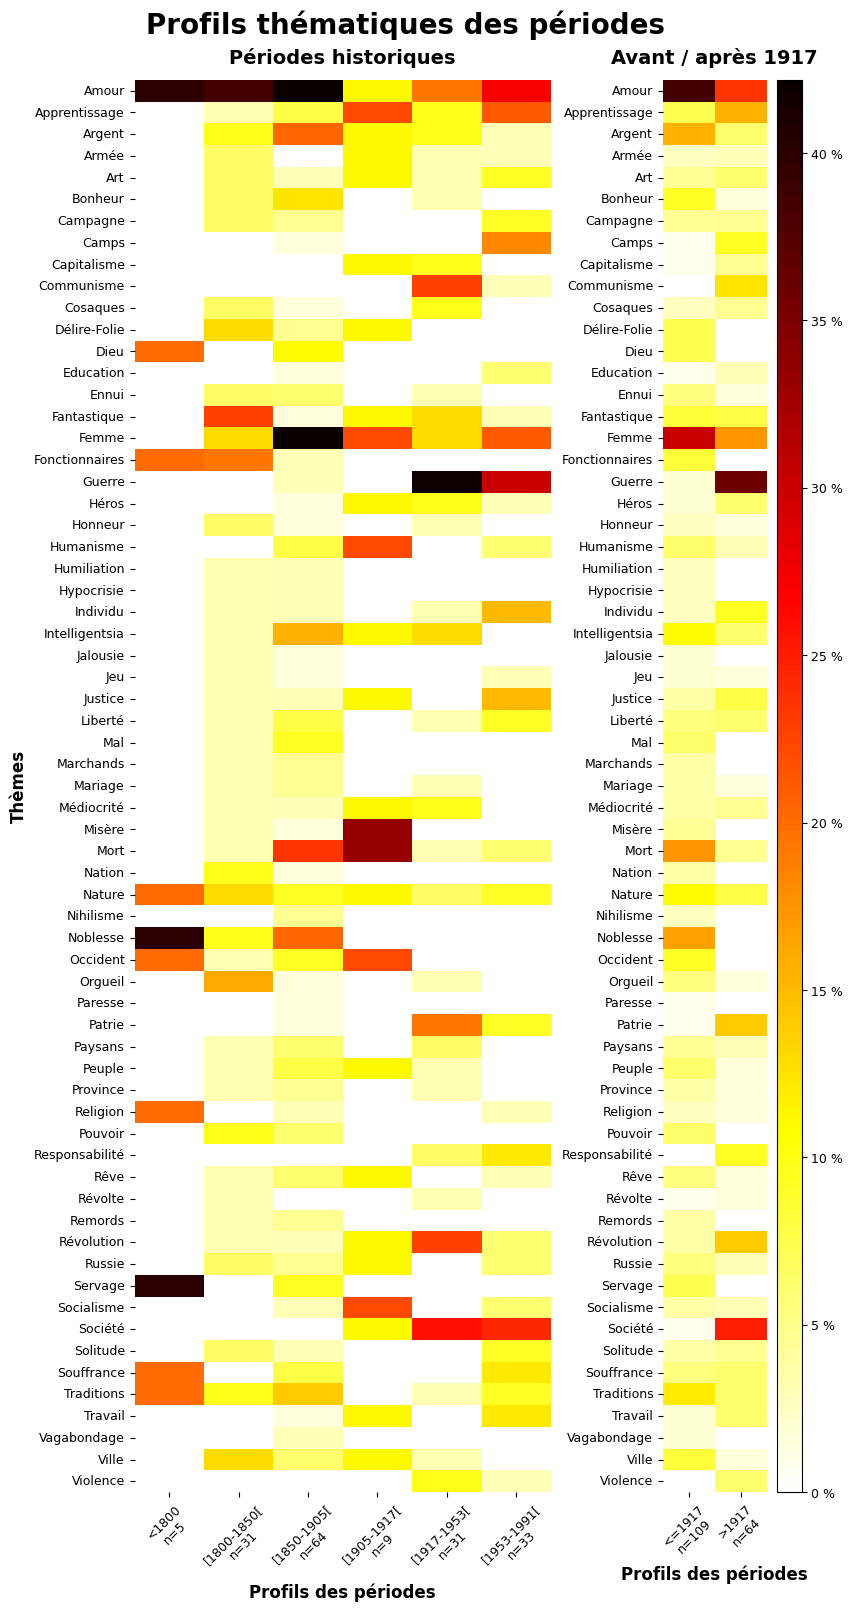

In [38]:
# graphique combiné

vmax = max(
    matrix_when_profile_pct.to_numpy().max(),
    matrix_cutoff_profile_pct.to_numpy().max()
)

norm = colors.Normalize(vmin=0, vmax=vmax)

fig, axes = plt.subplots(
    1, 2,
    figsize=(8, 16),
    gridspec_kw={"width_ratios": [3, 1]},
    constrained_layout=True
)

im = heatmap_profile(
    fig,
    axes[0],
    matrix_when_profile_pct_plot,
    "Périodes historiques",
    norm,
    show_yticklabels=True,
    show_ylabel=True
)

heatmap_profile(
    fig,
    axes[1],
    matrix_cutoff_profile_pct_plot,
    "Avant / après 1917",
    norm,
    show_yticklabels=True,
    show_ylabel=False
)

divider = make_axes_locatable(axes[1])

cax = divider.append_axes(
    "right",
    size=0.25,
    pad=0.10
)

cbar = fig.colorbar(im, cax=cax)

cbar.ax.tick_params(labelsize=9)

ticks = cbar.get_ticks()
ticks = ticks[ticks <= vmax]

cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{x:g} %" for x in ticks])

fig.suptitle(
    "Profils thématiques des périodes",
    fontsize=20,
    fontweight="bold"
)

fig.savefig(
    IMG_DIR / "profils_thématiques_périodes_combinés.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**barplot horizontal des thèmes les plus surreprésentés avant et après 1917** <br>

In [39]:
# nombre de thèmes à afficher de chaque côté

nb_themes = 15

# copie de sécurité

data_1917 = matrix_all_extended.copy()

# s'assurer que Composed est bien numérique

data_1917["Composed"] = pd.to_numeric(
    data_1917["Composed"],
    errors="coerce"
)

# création de la variable avant / après 1917

data_1917["Avant_apres_1917"] = np.where(
    data_1917["Composed"] < 1917,
    "Avant 1917",
    "Après 1917"
)

# profil thématique en pourcentage

profile_1917_pct = (
    data_1917
    .groupby("Avant_apres_1917")[theme_cols]
    .mean()
    * 100
)

# on impose l'ordre des lignes

profile_1917_pct = profile_1917_pct.loc[
    ["Avant 1917", "Après 1917"]
]

# calcul de l'écart : après - avant

df_ecarts = pd.DataFrame({
    "Avant 1917": profile_1917_pct.loc["Avant 1917"],
    "Après 1917": profile_1917_pct.loc["Après 1917"]
})

df_ecarts["Écart après - avant"] = (
    df_ecarts["Après 1917"] 
    - df_ecarts["Avant 1917"]
)

# thèmes les plus surreprésentés après 1917

themes_apres = (
    df_ecarts
    .sort_values("Écart après - avant", ascending=False)
    .head(nb_themes)
)

# thèmes les plus surreprésentés avant 1917

themes_avant = (
    df_ecarts
    .sort_values("Écart après - avant", ascending=True)
    .head(nb_themes)
)

# combinaison des deux ensembles

df_plot = pd.concat([themes_avant, themes_apres])

# tri pour avoir un graphique divergent lisible

df_plot = df_plot.sort_values("Écart après - avant")

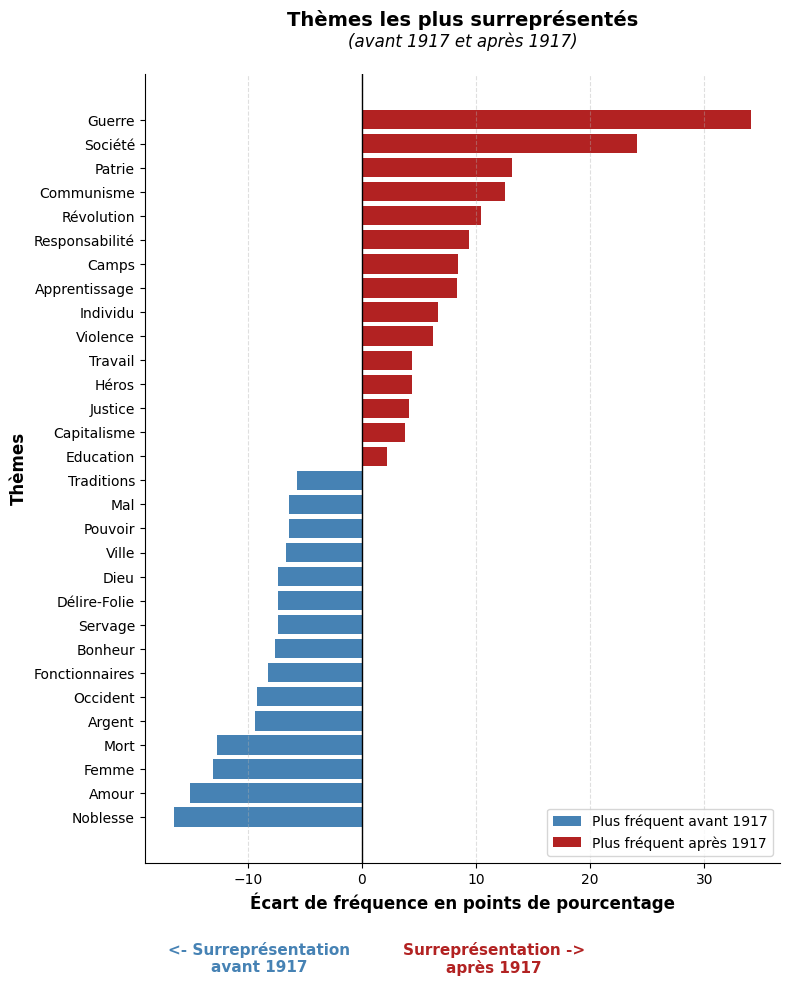

In [40]:
# graphique

fig, ax = plt.subplots(figsize=(8, 10))

valeurs = df_plot["Écart après - avant"]

couleurs = [
    "steelblue" if x < 0 else "firebrick"
    for x in valeurs
]

ax.barh(
    df_plot.index,
    valeurs,
    color=couleurs
)

# ligne verticale zéro
ax.axvline(
    x=0,
    color="black",
    linewidth=1
)

ax.set_xlabel(
    "Écart de fréquence en points de pourcentage",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Thèmes",
    fontsize=12,
    fontweight="bold"
)

# labels explicites sous les deux côtés de l'axe
ax.text(
    0.18, -0.10,
    "<- Surreprésentation\navant 1917",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=11,
    color="steelblue",
    fontweight="bold"
)

ax.text(
    0.55, -0.10,
    "Surreprésentation ->\naprès 1917",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=11,
    color="firebrick",
    fontweight="bold"
)

# grille verticale légère
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

# nettoyage
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# légende explicite
legend_elements = [
    Patch(
        facecolor="steelblue",
        label="Plus fréquent avant 1917"
    ),
    Patch(
        facecolor="firebrick",
        label="Plus fréquent après 1917"
    )
]

ax.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=10,
    frameon=True
)

fig.tight_layout(rect=[0, 0, 1, 0.93])

titres(
    fig,
    ax,
    t1="Thèmes les plus surreprésentés", y1=35,
    t2="(avant 1917 et après 1917)", y2=20,
    t3=" ", y3=7
)

plt.savefig(
    IMG_DIR / "themes_surrepresentes_avant_apres_1917.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
